# Python Controle Discret

In [1]:
from Models.BallBeam import ballbeam_config
from Models.BallBeam.StateSpace import StateSpaceModel
from Models.BallBeam.TransferFunctions import TransferFunctionModel

from Simulation.simulation import TFSimulator
from Simulation.simulation import HybridSim

from Simulation.runners import *

from Metrics_Plotting.SimLog import SimLog
from Metrics_Plotting.Plotting import Plotting

from Control.DiscretePID import DiscretePID
from Control.RSTController import RSTController

import numpy as np
import control as ct
import matplotlib.pyplot as plt



In [2]:
%matplotlib inline

## Mise en place

#### Système
Ici, on spécifie l'état initial, la méthode TransferFunctionModel() donne sa fonction de tranfert qu'on met ensuite dans le simualteur de fonctions de transfert

In [3]:
X_0 = np.array([[0], [0]])
model = TransferFunctionModel(ballbeam_config)
plant_sim = TFSimulator(model.Tf_dis, 0)

Les paramètres de la simulation (Temps total et période d'échantillonage se trouvent dans le fichier Models/Ballbeam/ballbeam_config.py) mais elles peuvent etre changés dirrectement dans le notebook. Par défaut le temps de simulation T est à 3 secondes et le temps d'échantillonage à 20 ms.

In [4]:
#ballbeam_config.dt=0.1 

#### Réponse inditielle et impultionelle 
Le but est de comparer notre simualtion a celle de la librairie python

1) Réponse impulsionelle

In [5]:
## simulateur 
impulse_logger=SimLog()
impulse_logger=run_discrete_impulse_response(plant_sim,ballbeam_config,0.0,impulse_logger)
## librairie python
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib = ct.impulse_response(model.Tf_dis, t)

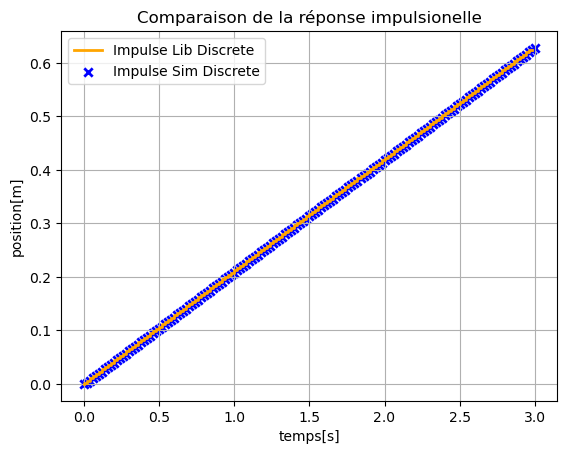

In [6]:
## affichage
fig1=plt.figure()
plt.step(
    t,
    y_lib,
    color='orange',
    linewidth=2,
    label="Impulse Lib Discrete"
)
plt.scatter(
    impulse_logger.t_hist,
    impulse_logger.y_hist,
    color='blue',
    marker='x',
    label="Impulse Sim Discrete",
    linewidth=2,
)


plt.grid()
plt.title('Comparaison de la réponse impulsionelle')
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')
#plt.savefig('Réponse_Impulsionelle_Discrete.png')
plt.show()


##### Réponse inditielle
Ici aussi, on utilise les run... pour simuler la réponse inditielle. Pour cela, on créé une nouvelle instance de SimLog

In [7]:
## simulateur 
step_logger=SimLog()
step_logger=run_discrete_step_response(plant_sim,ballbeam_config,0.0,step_logger)
## librairie python
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib = ct.step_response(model.Tf_dis, t)

In [8]:
_, y_lib = ct.step_response(model.Tf_cont, t)

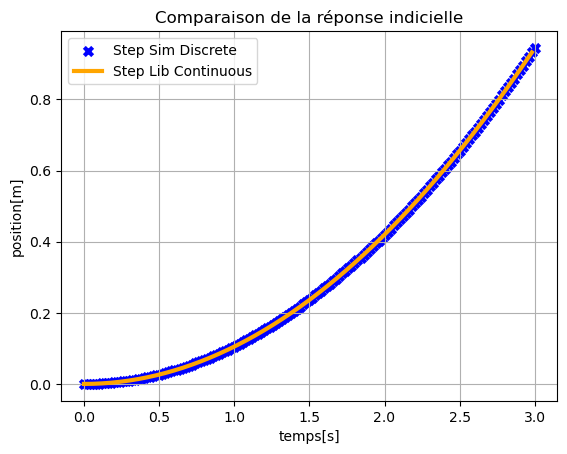

In [9]:
fig3=plt.figure()
plt.scatter(
    step_logger.t_hist,
    step_logger.y_hist,
    color='blue',
    marker='x',
    label="Step Sim Discrete",
    linewidth=3,
)

plt.plot(
    t,
    y_lib,
    color='orange',
    linestyle='-',
    linewidth=3,
    label="Step Lib Continuous"
)
plt.grid()
plt.title('Comparaison de la réponse indicielle')
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')
#plt.savefig('Réponse_Indicielle_Continue.png')
plt.show()


## Controle PID et validation


#### Mise en place du PID
On peut changer la duréé de simulation en mettant ballbeam_config.T= varaible . L'instance du PID discret est initalisé avec DiscretePID().

In [10]:
ballbeam_config.T=6

#### Modele en espace d'états (utilisé pour la simulation hybride)
Pour initailiser le simulateur continu, on lui met en entrée le ficher python contenant les matrices d'état 

In [11]:
StateSpace_Ball_Beam=StateSpaceModel(ballbeam_config)
hybrid_loop=HybridSim(StateSpace_Ball_Beam,ballbeam_config)


La fonction run_continuous_step_response prends en entrée le simulateur continu, l'état initial du système, et l'enregistreur 

In [12]:
logger_hybrid_step = SimLog()
logger_hybrid_step = run_continuous_step_response(hybrid_loop, X_0,logger_hybrid_step)

In [13]:
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib1 = ct.step_response(model.Tf_cont, t)

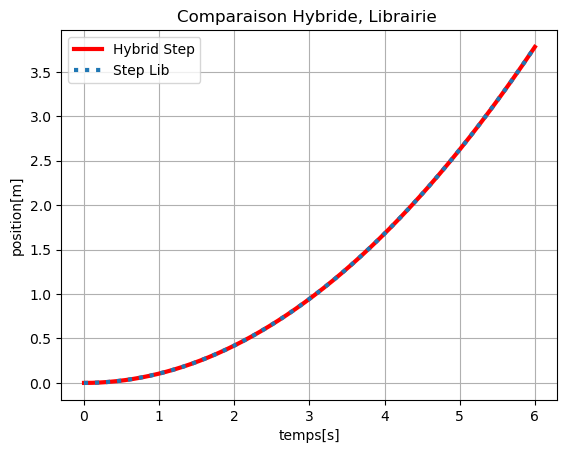

In [14]:
plt.figure()

plt.plot(
    logger_hybrid_step.t_hist,
    logger_hybrid_step.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Step"
)
plt.plot(
    t,
    y_lib1,
    linestyle=':',
    linewidth=3,
    label="Step Lib"
)
plt.title("Comparaison Hybride, Librairie ")
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')
#plt.savefig('Réponse_Indicielle_Hybride.png')
plt.show()

La boucle fermée hybride est simulée par run_continuous_control_loop(), tout controleur qui est mis en entrée de cette fonction doit avoir la méthode setReference() et step().
Pour configurer le PID, il lui faut l'initialiser avec ses paramètres.

In [15]:
kp, ki, kd = 150,100, 100
r = 1.0
PID = DiscretePID(kp,ki,kd,ballbeam_config.dt)
#PID.reset()

In [16]:
logger_hybrid = SimLog()
logger_hybrid = run_continuous_control_loop(hybrid_loop,PID,r,X_0,logger_hybrid)


In [17]:
L = PID.transferFunction * model.Tf_dis
T = ct.feedback(L, 1)

t = np.arange(
    0,
    ballbeam_config.T,
    ballbeam_config.dt
)

_, y_lib = ct.step_response(T, t)

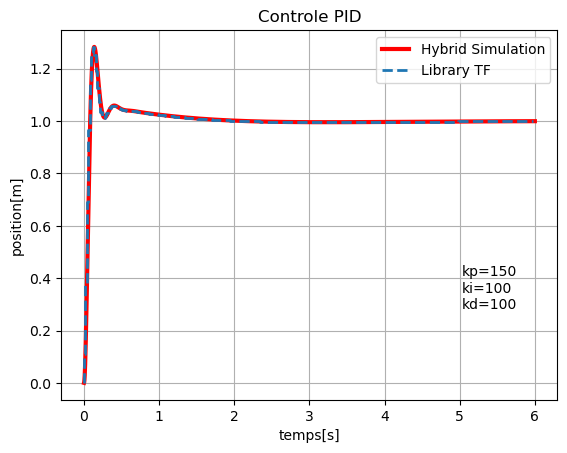

In [18]:
plt.figure()

plt.plot(
    logger_hybrid.t_hist,
    logger_hybrid.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Simulation"
)
plt.step(t, y_lib, label="Library TF",linewidth=2,
    linestyle='--',)
plt.title("Controle PID")
text='kp='+str(kp)+'\n'+'ki='+str(ki)+'\n'+'kd='+str(kd)
plt.figtext(0.75,0.3,text)
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Réponse_Indicielle_PID.png')
plt.show()


Outil pour exporter un enregistreur sous forme de fichier CSV

In [19]:
from Utils import utils
#utils.as_csv('hybridLog',logger_hybrid)

Controle RST, les polynomes R, S et T doivent etre entrés dans RSTController() \
Ici, on a utilisé le PID discret changé en structure RST

In [20]:
rst=RSTController(PID.R,PID.S,PID.T)
logger_rst = SimLog()
logger_rst = run_continuous_control_loop(hybrid_loop,rst,r,X_0,logger_rst)

FF: 5300.0000 | FB: 0.0000 | u_before_S: 5300.0000
FF: -5146.0000 | FB: 589.8900 | u_before_S: -5904046.0000
FF: 2.0000 | FB: -655628.4546 | u_before_S: 6556284548.0000
FF: 2.0000 | FB: 728054553.0639 | u_before_S: -7280545530637.3604
FF: 2.0000 | FB: -808481428822.0856 | u_before_S: 8084814288220858.0000
FF: 2.0000 | FB: 897792916749182.0000 | u_before_S: -8977929167491819520.0000
FF: 2.0000 | FB: -996970483959473152.0000 | u_before_S: 9969704839594731634688.0000
FF: 2.0000 | FB: 1107104018469403623424.0000 | u_before_S: -11071040184694035582025728.0000
FF: 2.0000 | FB: -1229403806262458446774272.0000 | u_before_S: 12294038062624583475605274624.0000
FF: 2.0000 | FB: 1365213831435831728821764096.0000 | u_before_S: -13652138314358317560896524648448.0000
FF: 2.0000 | FB: -1516026545590350932109967753216.0000 | u_before_S: 15160265455903508280768163609575424.0000
FF: 2.0000 | FB: 1683499268768314771799478257057792.0000 | u_before_S: -16834992687683148234503616634445365248.0000
FF: 2.0000 

c:\Users\adamc\OneDrive\Bureau\PyControl\PythonDiscreteControl_Dev\Control\RSTController.py:62: RuntimeWarning: overflow encountered in scalar multiply
  v_k = np.dot(self.T_coeffs, self.r_hist) - np.dot(
c:\Users\adamc\OneDrive\Bureau\PyControl\PythonDiscreteControl_Dev\Simulation\simulation.py:123: RuntimeWarning: invalid value encountered in matmul
  return self.A @ X + self.B @ u_k


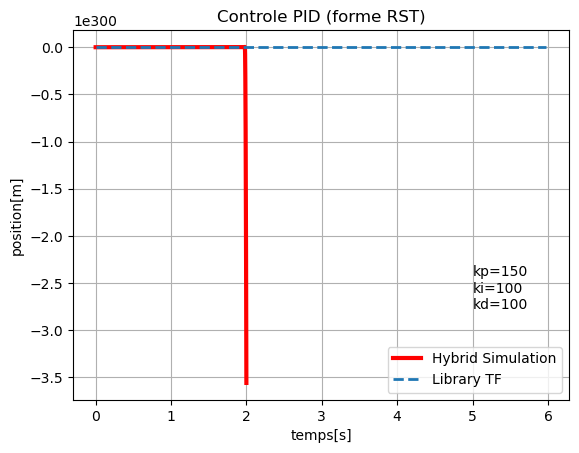

In [21]:
plt.figure()

plt.plot(
    logger_rst.t_hist,
    logger_rst.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Simulation"
)
plt.step(t, y_lib, label="Library TF",linewidth=2,
    linestyle='--',)
plt.title("Controle PID (forme RST)")
text='kp='+str(kp)+'\n'+'ki='+str(ki)+'\n'+'kd='+str(kd)
plt.figtext(0.75,0.3,text)
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Réponse_Indicielle_PID.png')
plt.show()


In [22]:
logger_discrete_control=SimLog()
logger_discrete_control=run_discrete_control(plant_sim,rst,ballbeam_config,1.0,0,logger_discrete_control)

FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_before_S: nan
FF: 2.0000 | FB: nan | u_

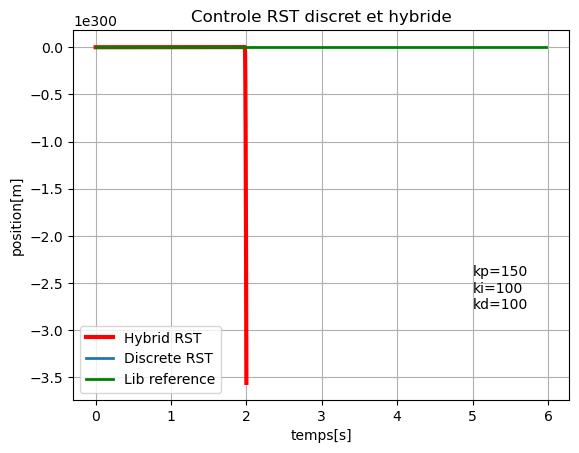

In [23]:
plt.figure()

plt.plot(
    logger_rst.t_hist,
    logger_rst.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid RST"
)
plt.step(logger_discrete_control.t_hist, logger_discrete_control.y_hist, label="Discrete RST",linewidth=2,
    linestyle='-',)
plt.step(t,y_lib,label="Lib reference",color="green",linewidth=2,
    linestyle='-',)
plt.title("Controle RST discret et hybride")
text='kp='+str(kp)+'\n'+'ki='+str(ki)+'\n'+'kd='+str(kd)
plt.figtext(0.75,0.3,text)
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Comparaision_hybride_discret_simu.png')
plt.show()


RST avec fonction de transfert en BF désirée 

In [24]:
omega_n = 5  # Natural frequency in rad/s
zeta = 0.707  # Damping ratio (optimal balance of speed and overshoot)

# Standard second-order form: omega_n^2 / (s^2 + 2*zeta*omega_n*s + omega_n^2)
num_cl = [omega_n**2]
den_cl = [1, 2 * zeta * omega_n, omega_n**2]
G_cl_continuous = ct.tf(num_cl, den_cl)

# Discretize the desired tracking target
desired_discrete = ct.c2d(G_cl_continuous,ballbeam_config.dt, method="zoh")

In [25]:
R,S,T=utils.Compute_Desired_RST(desired_discrete,model.Tf_dis)


--- New Causal RST Synthesis ---
Closed-loop poles roots: [0.92941229+0.0658391j 0.92941229-0.0658391j]
Poles magnitude: [0.93174137 0.93174137]
S coefficients: [0.93174164]
R coefficients: [ 1625.19905442 -1514.27748265]
T coefficients: [56.76781182 54.15375995]


In [26]:
rst_2=RSTController(R,S,T)
logger_rst_test = SimLog()
logger_rst_test = run_continuous_control_loop(hybrid_loop,rst_2,1.0,X_0,logger_rst_test)

FF: 56.7678 | FB: 0.0000 | u_before_S: 56.7678
FF: 110.9216 | FB: 0.0000 | u_before_S: 110.9079
FF: 110.9216 | FB: 0.0000 | u_before_S: 110.8411
FF: 110.9216 | FB: 0.0000 | u_before_S: 110.6715
FF: 110.9216 | FB: 0.0001 | u_before_S: 110.3526
FF: 110.9216 | FB: 0.0001 | u_before_S: 109.8415
FF: 110.9216 | FB: 0.0002 | u_before_S: 109.0983
FF: 110.9216 | FB: 0.0003 | u_before_S: 108.0860
FF: 110.9216 | FB: 0.0004 | u_before_S: 106.7709
FF: 110.9216 | FB: 0.0006 | u_before_S: 105.1217
FF: 110.9216 | FB: 0.0008 | u_before_S: 103.1103
FF: 110.9216 | FB: 0.0010 | u_before_S: 100.7112
FF: 110.9216 | FB: 0.0013 | u_before_S: 97.9019
FF: 110.9216 | FB: 0.0016 | u_before_S: 94.6624
FF: 110.9216 | FB: 0.0020 | u_before_S: 90.9759
FF: 110.9216 | FB: 0.0024 | u_before_S: 86.8281
FF: 110.9216 | FB: 0.0029 | u_before_S: 82.2077
FF: 110.9216 | FB: 0.0034 | u_before_S: 77.1062
FF: 110.9216 | FB: 0.0039 | u_before_S: 71.5181
FF: 110.9216 | FB: 0.0045 | u_before_S: 65.4408
FF: 110.9216 | FB: 0.0052 | u_

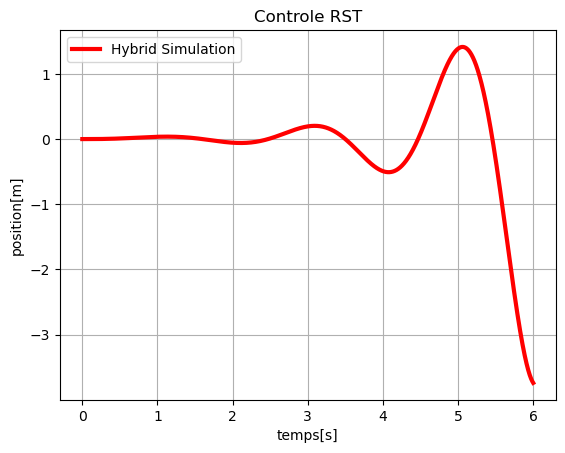

In [27]:
plt.figure()

plt.plot(
    logger_rst_test.t_hist,
    logger_rst_test.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Simulation"
)

plt.title("Controle RST")
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Réponse_Indicielle_PID.png')
plt.show()

In [28]:
utils.as_csv('RSTLog',logger_rst_test)